In [1]:
from pathlib import Path
import importlib
import functions
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
importlib.reload(functions)
from tqdm.notebook import tqdm
import math
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score,
    precision_recall_curve, average_precision_score, accuracy_score
)
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [6]:
PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "datasets/RF"
OUTPUT_FIG = PROJECT_ROOT / "figures/RF"
OUTPUT_IMP = PROJECT_ROOT / "datasets/FeatureImp"
OUTPUT_TEX = PROJECT_ROOT / "tex/RF"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_IMP.mkdir(parents=True, exist_ok=True)
OUTPUT_TEX.mkdir(parents=True, exist_ok=True)

In [3]:
aap_symbols = pd.read_csv(PROJECT_ROOT / 'datasets/exp_mat_unscaled.csv', index_col=0).index
aap_symbols

Index(['CYSLTR1', 'PRXL2B', 'PTGS2', 'PTGER4', 'PNPLA8', 'LIPA', 'PTGER2',
       'LTB4R', 'ABCC1', 'CYSLTR2',
       ...
       'GPX7', 'PLA2G4A', 'EPHX2', 'ACOT11', 'ABCC6', 'MGST3', 'ACSL4',
       'CYP4F3', 'ALOX15B', 'LTA4H'],
      dtype='object', length=103)

In [4]:
#whole dataset
dataset = functions.GeneExpressionDataset(
    exp_matrix_path= PROJECT_ROOT / 'datasets/exp_mat_unscaled.csv',
    conf_matrix_path= PROJECT_ROOT / 'datasets/adj_giant.csv',
    threshold=0.1
)

k = 10
n = 9
split_seed = 1905
y = np.array([data.y.item() for data in dataset])
country = np.array(dataset.country)
strat = np.array([f"{label}__{group}" for label, group in zip(y, country)])
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=split_seed)

In [7]:
from sklearn.ensemble import RandomForestClassifier

D = np.array([data.y.item() for data in dataset])

folds: [np.ndarray] = []
for _, fold_idx in skf.split(np.zeros(len(D)), strat):
    folds.append(fold_idx)

H = functions.sample_hyperparams(model_type="RF", n=n, seed=2026)
t_scores = []
importances = []

all_y_true = []
all_y_pred = []
cms = []

shap_values_test_folds = []
expected_values = []
X_test_list = []
X_unscaled_test_list = []
all_probas = []

metrics_u_j = {
    "Accuracy": pd.DataFrame(columns=range(k)),
    "F1": pd.DataFrame(columns=range(k)),
    "Precision": pd.DataFrame(columns=range(k)),
    "Recall": pd.DataFrame(columns=range(k)),
    "AUC-PRC": pd.DataFrame(columns=range(k)),
    "AUC-ROC": pd.DataFrame(columns=range(k))
}
metrics_t = {
    "Accuracy": np.array([]),
    "F1": np.array([]),
    "Precision": np.array([]),
    "Recall": np.array([]),
    "AUC-PRC": np.array([]),
    "AUC-ROC": np.array([])
}

#Progress bar
total = k*n*(k-1)
pbar = tqdm(total=total, desc="Verarbeitung läuft")

for i in range(k):
    test_idx = folds[i]
    # Outer folds
    other_fold_ids = [m for m in range(k) if m != i]
    best_j = None
    best_ubar = -math.inf

    for j, h_j in enumerate(H):
        u_vals = {m: [] for m in metrics_u_j.keys()}

        # inner CV loop
        for m in other_fold_ids:
            val_idx = folds[m]
            train_fold_ids = [r for r in range(k) if r not in (i, m)]
            train_idx = np.concatenate([folds[r] for r in train_fold_ids], axis=0)

            pd.DataFrame(train_idx, columns=["index"]).to_csv(OUTPUT_DIR / f"fold_{m}_train.csv", index=False)
            pd.DataFrame(val_idx, columns=["index"]).to_csv(OUTPUT_DIR / f"fold_{m}_val.csv", index=False)
            functions.removeBatchEffect(OUTPUT_DIR / f"fold_{m}_train.csv",
                      OUTPUT_DIR / f"fold_{m}_val.csv",
                      str(m), "RF")

            train_dataset = functions.GeneExpressionDataset(
                exp_matrix_path=OUTPUT_DIR / f"train_corrected_{m}.csv",
                conf_matrix_path=PROJECT_ROOT / "datasets" / 'adj_giant.csv',
                threshold=0.1
            )
            val_dataset = functions.GeneExpressionDataset(
                exp_matrix_path=OUTPUT_DIR / f"val_corrected_{m}.csv",
                conf_matrix_path=PROJECT_ROOT / "datasets" / 'adj_giant.csv',
                threshold=0.1
            )
            
            scaler = StandardScaler()
            scaler.fit(train_dataset.expr)
            
            X_train = scaler.transform(train_dataset.expr)
            y_train = train_dataset.labels
            X_val = scaler.transform(val_dataset.expr)
            y_val = val_dataset.labels
                        
            rf = RandomForestClassifier(
                n_estimators=h_j['n_estimators'],
                max_depth=h_j['max_depth'],
                min_samples_split=h_j['min_samples_split'],
                min_samples_leaf=h_j['min_samples_leaf'],
                random_state=2026,
                class_weight="balanced"
            )
            rf.fit(X_train, y_train)
            y_pred = rf.predict(X_val)
            y_prob = rf.predict_proba(X_val)[:,1]
            
            u_vals['Precision'].append(precision_score(y_val, y_pred, average="macro", zero_division=0))
            u_vals['Recall'].append(recall_score(y_val, y_pred, average="macro", zero_division=0))
            u_vals['Accuracy'].append(accuracy_score(y_val, y_pred))
            u_vals['F1'].append(f1_score(y_val, y_pred, average="macro", zero_division=0))
            u_vals['AUC-PRC'].append(average_precision_score(y_val, y_prob))
            u_vals['AUC-ROC'].append(roc_auc_score(y_val, y_prob))
            pbar.update(1)

        ubar_j = float(np.mean(u_vals["Recall"]))
        for metric in metrics_u_j.keys():
            mean = np.mean(u_vals[metric])
            std = np.std(u_vals[metric])
            metrics_u_j[metric].loc[j, i] = f"{mean:.3f} ± {std:.3f}" 

        if ubar_j > best_ubar:
            best_ubar = ubar_j
            best_j = j
    
    assert best_j is not None
    h_star = H[best_j]

    #outer cv loop
    train_idx_full = np.concatenate([folds[r] for r in range(k) if r != i], axis=0)

    pd.DataFrame(train_idx_full, columns=["index"]).to_csv(OUTPUT_DIR / f"fold_{i}_train_full.csv", index=False)
    pd.DataFrame(test_idx, columns=["index"]).to_csv(OUTPUT_DIR / f"fold_{i}_test.csv", index=False)
    functions.removeBatchEffect(OUTPUT_DIR / f"fold_{i}_train_full.csv",
                      OUTPUT_DIR / f"fold_{i}_test.csv",
                      str(i), "RF")

    train_dataset = functions.GeneExpressionDataset(
        exp_matrix_path=OUTPUT_DIR / f"train_corrected_{i}.csv",
        conf_matrix_path=PROJECT_ROOT /"datasets" / 'adj_giant.csv',
        threshold=0.1
    )
    test_dataset = functions.GeneExpressionDataset(
        exp_matrix_path=OUTPUT_DIR / f"test_corrected_{i}.csv",
        conf_matrix_path=PROJECT_ROOT / "datasets" / 'adj_giant.csv',
        threshold=0.1
    )
    
    scaler = StandardScaler()
    scaler.fit(train_dataset.expr)

    X_train = scaler.transform(train_dataset.expr)
    y_train = train_dataset.labels
    X_test = scaler.transform(test_dataset.expr)
    y_test = test_dataset.labels

    rf = RandomForestClassifier(
                n_estimators=h_star['n_estimators'],
                max_depth=h_star['max_depth'],
                min_samples_split=h_star['min_samples_split'],
                min_samples_leaf=h_star['min_samples_leaf'],
                random_state=2026,
                class_weight="balanced"
            )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:,1]

    metrics_t['Precision'] = np.append(metrics_t['Precision'], precision_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_t['Recall'] = np.append(metrics_t['Recall'], recall_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_t['Accuracy'] = np.append(metrics_t['Accuracy'], accuracy_score(y_test, y_pred))
    metrics_t['F1'] = np.append(metrics_t['F1'], f1_score(y_test, y_pred, average="macro", zero_division=0))
    metrics_t['AUC-PRC'] = np.append(metrics_t['AUC-PRC'], average_precision_score(y_test, y_prob))
    metrics_t['AUC-ROC'] = np.append(metrics_t['AUC-ROC'], roc_auc_score(y_test, y_prob))

    X_test_list.append(X_test)
    X_unscaled_test_list.append(test_dataset.expr)
    
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)
    shap_values_test_folds.append(shap_values)
    expected_values.extend([explainer.expected_value[1]] * len(X_test))
    all_probas.append(y_prob)
    
    t_scores.append(accuracy_score(y_test, y_pred))
    all_y_true.append(y_test)
    all_y_pred.append(y_pred)
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    cms.append(cm)
pbar.close()
    
mean = float(np.mean(t_scores))
std = float(np.std(t_scores, ddof=1))
print(mean, std)

Verarbeitung läuft:   0%|          | 0/810 [00:00<?, ?it/s]

0.6617305458768873 0.047623178578739295


In [8]:
H

[{'model': 'RF',
  'n_estimators': np.int64(800),
  'max_depth': np.int64(3),
  'min_samples_split': np.int64(10),
  'min_samples_leaf': np.int64(15)},
 {'model': 'RF',
  'n_estimators': np.int64(500),
  'max_depth': np.int64(4),
  'min_samples_split': np.int64(10),
  'min_samples_leaf': np.int64(10)},
 {'model': 'RF',
  'n_estimators': np.int64(500),
  'max_depth': np.int64(4),
  'min_samples_split': np.int64(50),
  'min_samples_leaf': np.int64(20)},
 {'model': 'RF',
  'n_estimators': np.int64(800),
  'max_depth': np.int64(6),
  'min_samples_split': np.int64(30),
  'min_samples_leaf': np.int64(5)},
 {'model': 'RF',
  'n_estimators': np.int64(800),
  'max_depth': np.int64(5),
  'min_samples_split': np.int64(10),
  'min_samples_leaf': np.int64(10)},
 {'model': 'RF',
  'n_estimators': np.int64(300),
  'max_depth': np.int64(6),
  'min_samples_split': np.int64(30),
  'min_samples_leaf': np.int64(20)},
 {'model': 'RF',
  'n_estimators': np.int64(300),
  'max_depth': np.int64(5),
  'min_samp

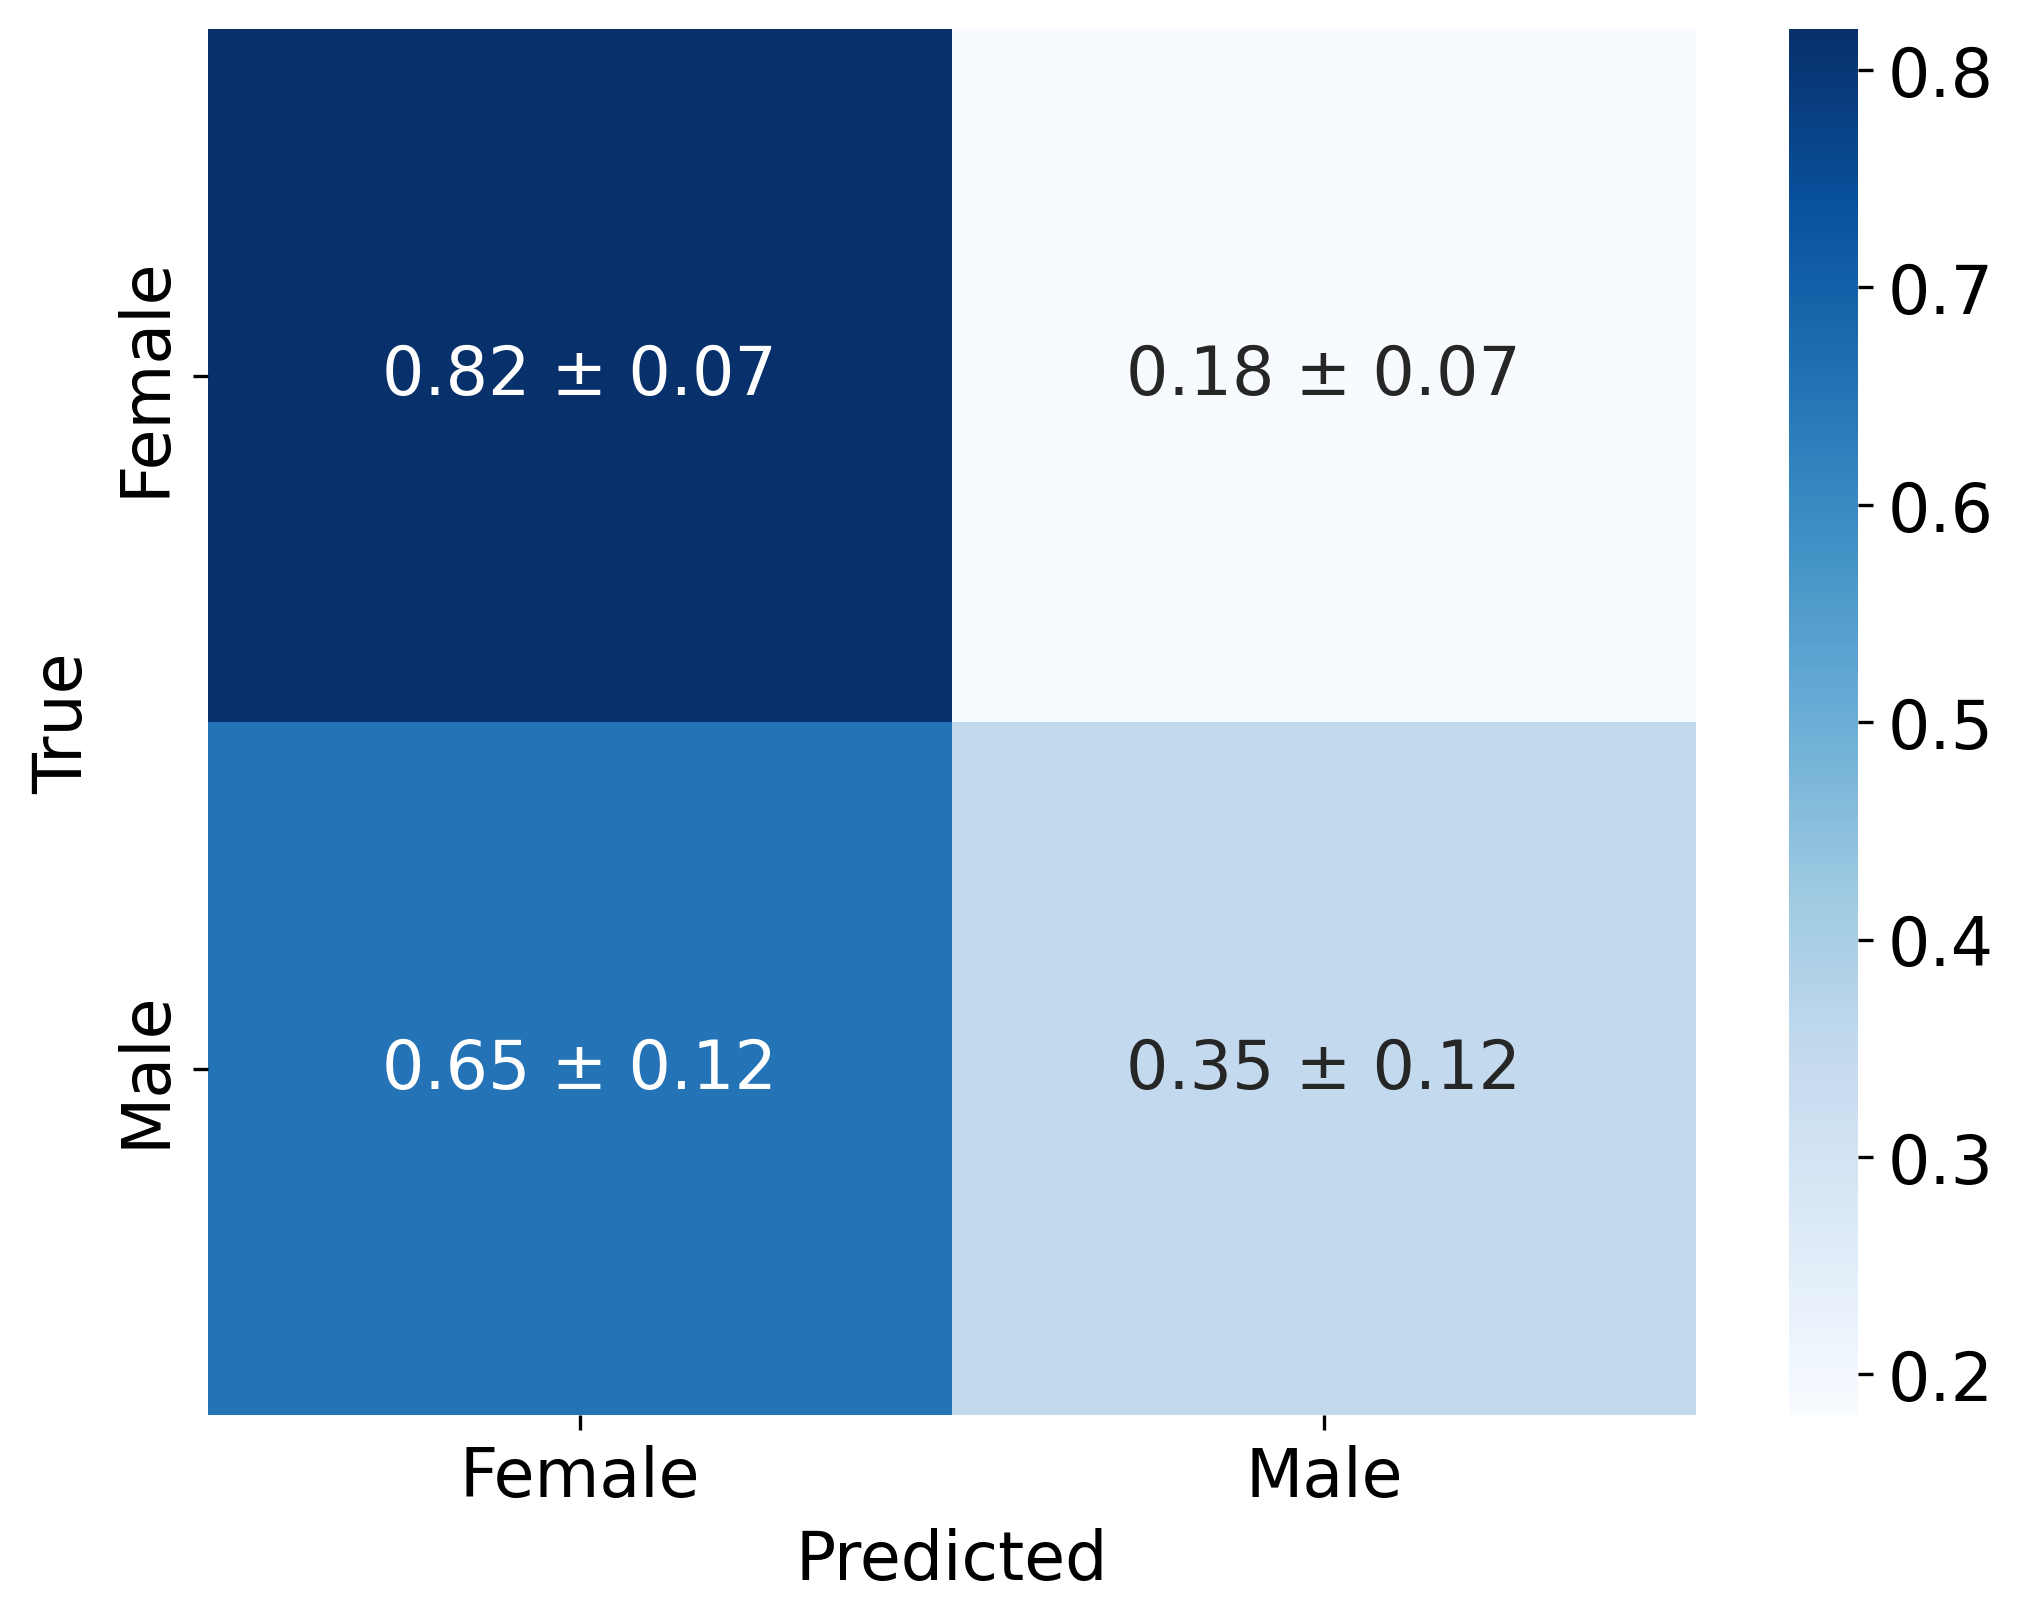

In [9]:
cms = np.array(cms)

cm_mean = np.mean(cms, axis=0)
cm_std  = np.std(cms, axis=0)

plt.figure(figsize=(8, 6), dpi=300)
labels = np.array([
    [f"{m:.2f} ± {s:.2f}" for m, s in zip(row_m, row_s)]
    for row_m, row_s in zip(cm_mean, cm_std)
])

labels_names = ["Female", "Male"]
ax = sns.heatmap(cm_mean, annot=labels, fmt="", cmap="Blues", xticklabels=labels_names, yticklabels=labels_names, annot_kws={"size": 16})
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_xlabel("Predicted", fontsize=16)
ax.set_ylabel("True", fontsize=16)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.savefig(OUTPUT_FIG / "confusion_matrix_rf.pdf", bbox_inches="tight")
plt.show()

In [14]:
#generates NACHOS Latex tables
for metric in metrics_u_j.keys():
    df_cv = metrics_u_j[metric]
    df_cv.columns = [f"F{i}" for i in range(10)]
    df_cv.index = [f"h_{i}" for i in range(9)]

    cross_scores = {f"t{i}": metrics_t[metric][i] for i in range(10)}
    functions.generate_table_nachos_tex(df_cv=df_cv,
                            caption="NACHOS " + metric + " results for " + H[0]['model'],
                            cross_scores=cross_scores,
                            metric=metric,
                            filename= OUTPUT_TEX / ("./table_nachos_" + metric + ".tex"),
                            label = "tab:" + H[0]['kernel'] + " " + H[0]['model'] + metric if H[0]['model'] == "SVM" 
                            else "tab:" + H[0]['model'] + metric)

In [15]:
metrics_t

{'Accuracy': array([0.71428571, 0.61904762, 0.64285714, 0.71428571, 0.73170732,
        0.58536585, 0.63414634, 0.65853659, 0.68292683, 0.63414634]),
 'F1': array([0.63049853, 0.43434343, 0.60501567, 0.67857143, 0.6479313 ,
        0.53063973, 0.5467944 , 0.53709677, 0.60722181, 0.56842105]),
 'Precision': array([0.68014706, 0.45394737, 0.60714286, 0.68700265, 0.72478992,
        0.53159341, 0.58333333, 0.55113636, 0.61060606, 0.5704023 ]),
 'Recall': array([0.625     , 0.48214286, 0.6037037 , 0.67407407, 0.64153439,
        0.53042328, 0.55641026, 0.5387931 , 0.60488506, 0.56730769]),
 'AUC-PRC': array([0.61240761, 0.43143088, 0.57628207, 0.72891037, 0.52743087,
        0.38111065, 0.57975069, 0.51166921, 0.50571799, 0.46951552]),
 'AUC-ROC': array([0.68112245, 0.56377551, 0.67901235, 0.74567901, 0.71428571,
        0.55820106, 0.67435897, 0.65229885, 0.59482759, 0.58516484])}

In [16]:
metrics_u_j

{'Accuracy':                 F0             F1             F2             F3  \
 h_0  0.626 ± 0.038  0.691 ± 0.052  0.672 ± 0.048  0.656 ± 0.048   
 h_1  0.626 ± 0.043  0.699 ± 0.066  0.699 ± 0.058  0.667 ± 0.066   
 h_2  0.637 ± 0.043  0.677 ± 0.059  0.677 ± 0.055  0.659 ± 0.063   
 h_3  0.642 ± 0.050  0.691 ± 0.064  0.691 ± 0.046  0.669 ± 0.055   
 h_4  0.656 ± 0.043  0.704 ± 0.067  0.691 ± 0.056  0.659 ± 0.043   
 h_5  0.637 ± 0.028  0.683 ± 0.062  0.683 ± 0.046  0.653 ± 0.065   
 h_6  0.634 ± 0.035  0.688 ± 0.065  0.688 ± 0.050  0.648 ± 0.042   
 h_7  0.634 ± 0.035  0.688 ± 0.065  0.688 ± 0.050  0.648 ± 0.042   
 h_8  0.626 ± 0.043  0.699 ± 0.066  0.699 ± 0.058  0.667 ± 0.066   
 
                 F4             F5             F6             F7  \
 h_0  0.651 ± 0.056  0.694 ± 0.031  0.644 ± 0.043  0.667 ± 0.050   
 h_1  0.659 ± 0.053  0.708 ± 0.027  0.662 ± 0.055  0.683 ± 0.063   
 h_2  0.657 ± 0.066  0.683 ± 0.047  0.641 ± 0.045  0.659 ± 0.059   
 h_3  0.673 ± 0.035  0.694 ± 0.031

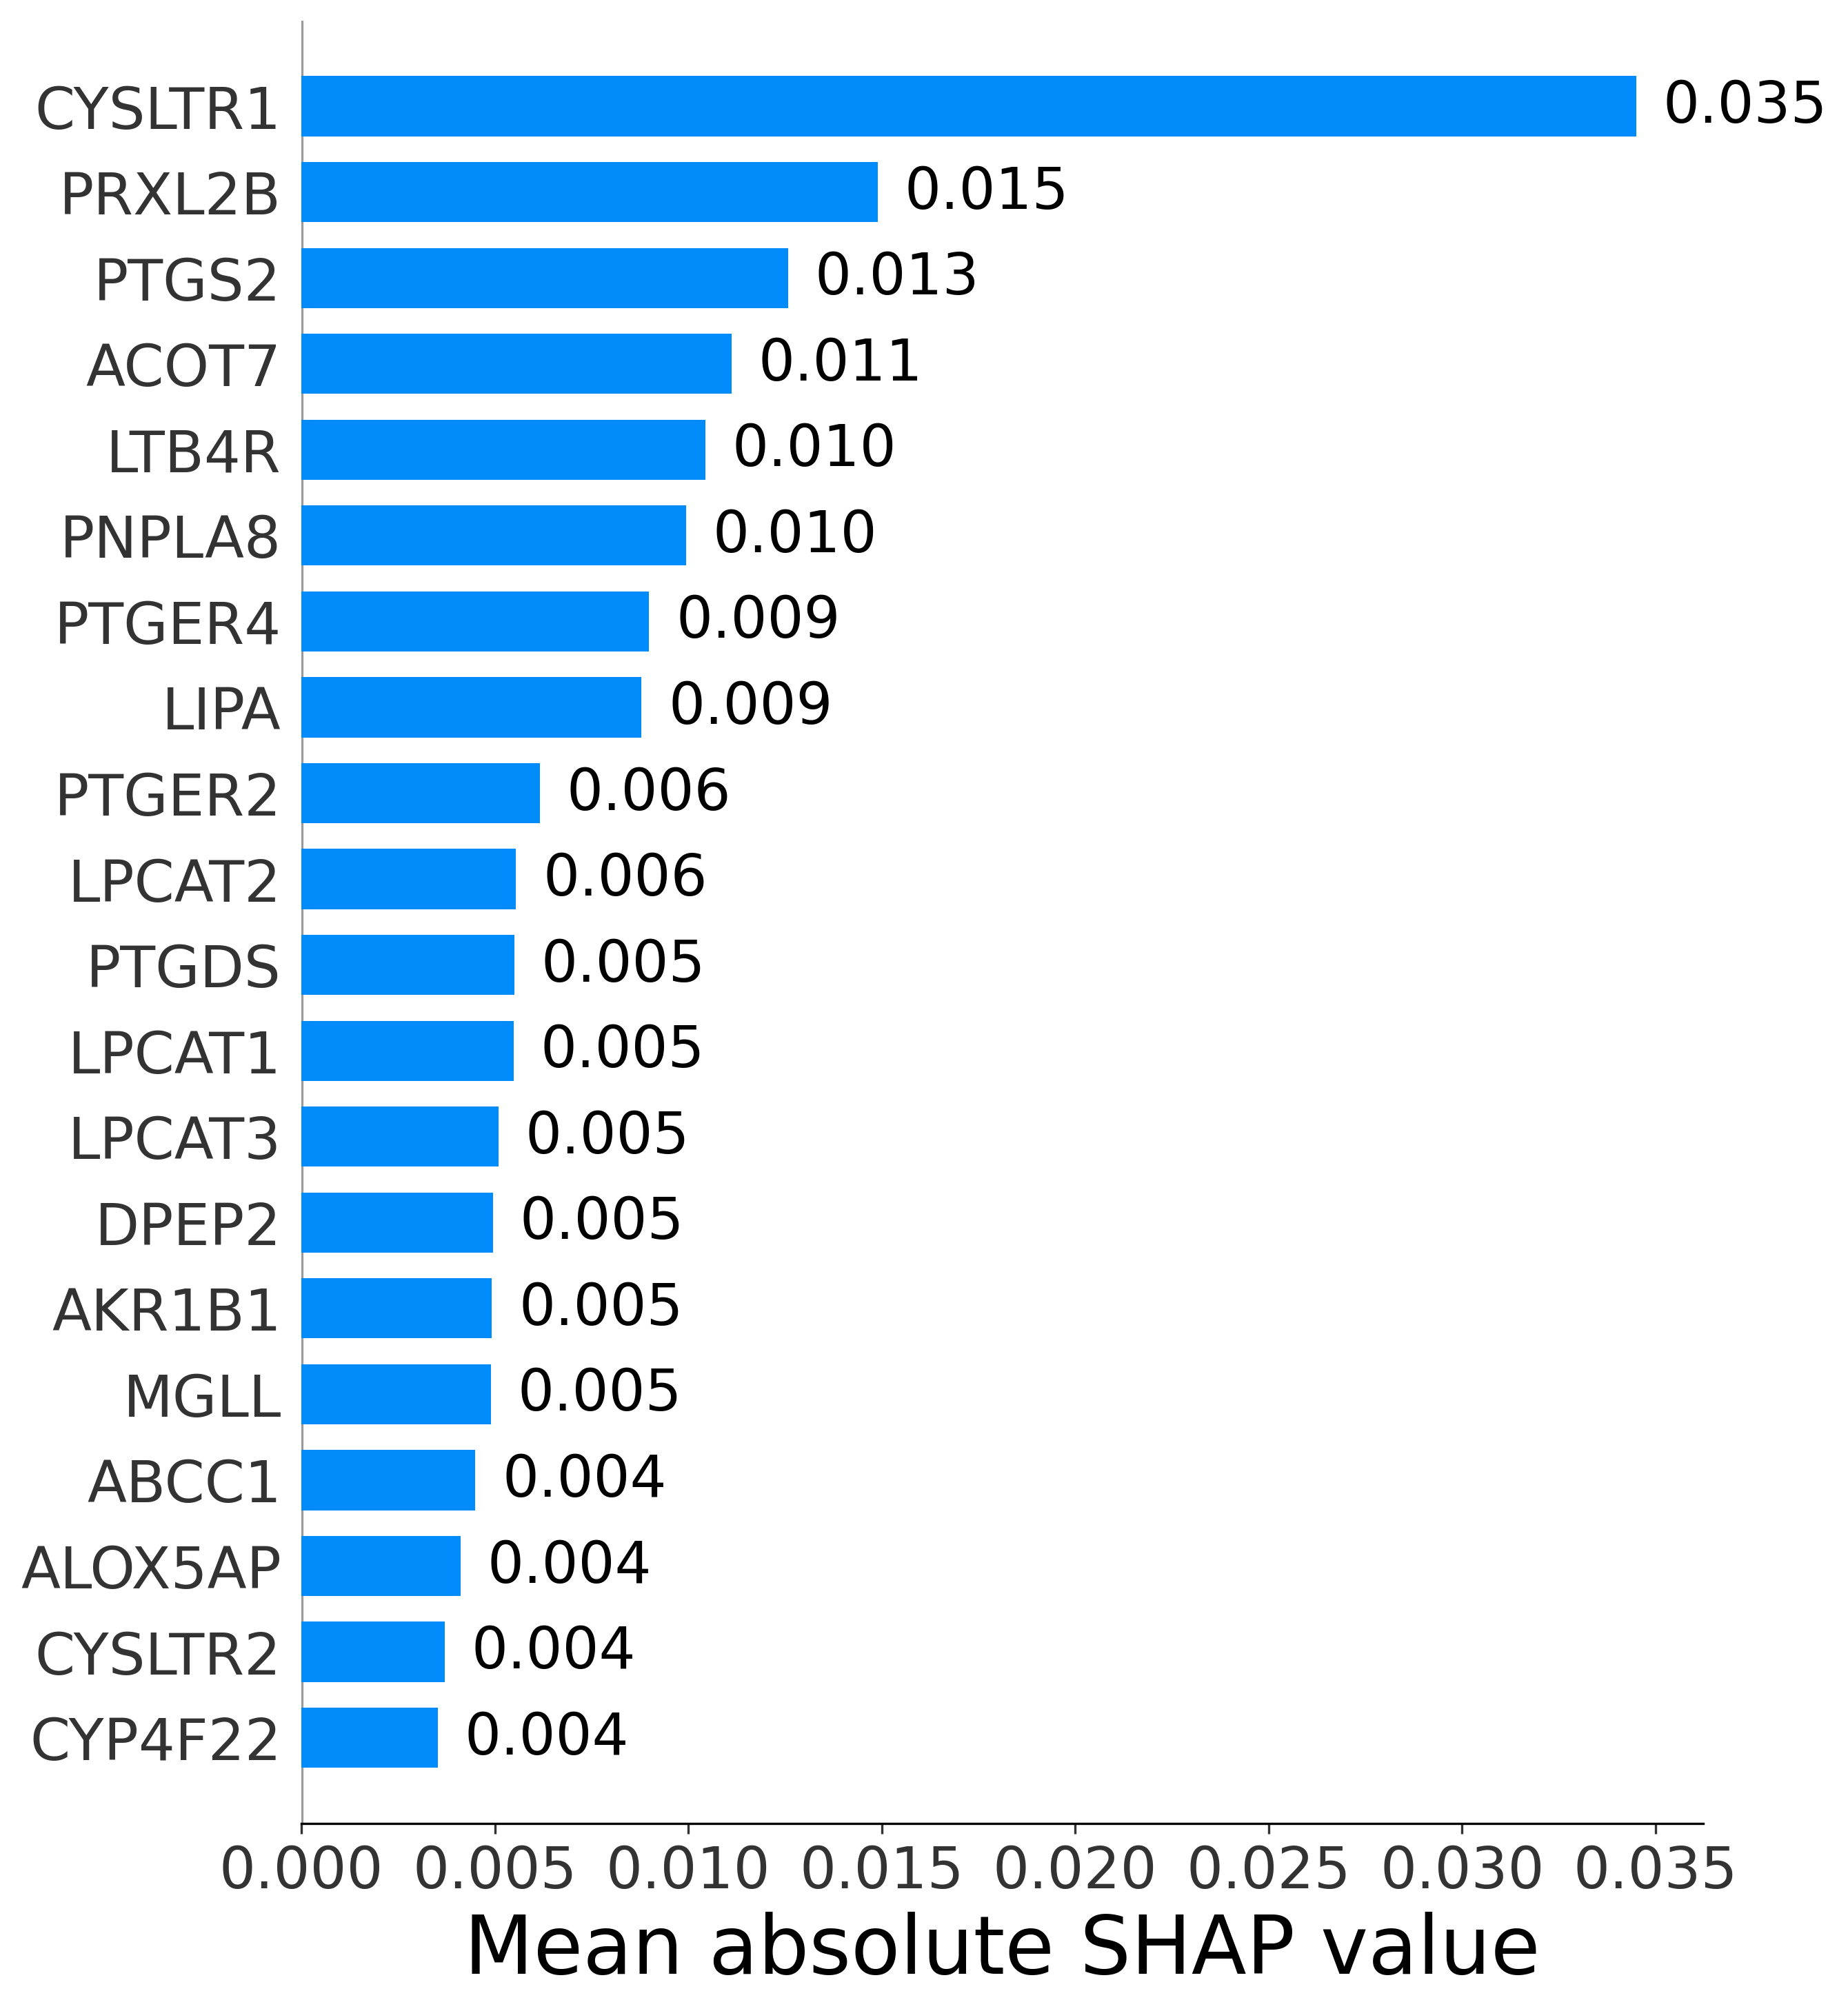

In [17]:
X_test_all = np.vstack(X_test_list)
X_unscaled_test_all = np.vstack(X_unscaled_test_list)
shap_all = np.vstack(shap_values_test_folds)
shap_all = shap_all[:, :, 1]


importance = np.mean(np.abs(shap_all), axis=0)
top_idx = np.argsort(importance)[::-1][:20]

pd.DataFrame({"Symbols": aap_symbols[np.argsort(importance)[::-1]], "RFImp": importance[np.argsort(importance)[::-1]]}).to_csv(OUTPUT_IMP / "rfimp.csv", index=False, sep=";")

shap_top = shap_all[:, top_idx]
X_top = X_test_all[:, top_idx]
importance_top = importance[top_idx]

fig = plt.figure(figsize=(12, 6),dpi=300)
shap.summary_plot(shap_all,X_test_all,plot_type="bar",feature_names=aap_symbols,show=False, max_display=20)
ax = plt.gca()
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel("Mean absolute SHAP value", fontsize=28)
offset = max(importance_top) * 0.02

for i, v in enumerate(importance_top[::-1]):
    ax.text(v + offset, i, f"{v:.3f}", va='center', fontsize=20)

plt.xlabel("Mean absolute SHAP value")
#fig.savefig(OUTPUT_FIG / "shap_summary_rf_bar.pdf", bbox_inches="tight")
plt.show()
plt.close()

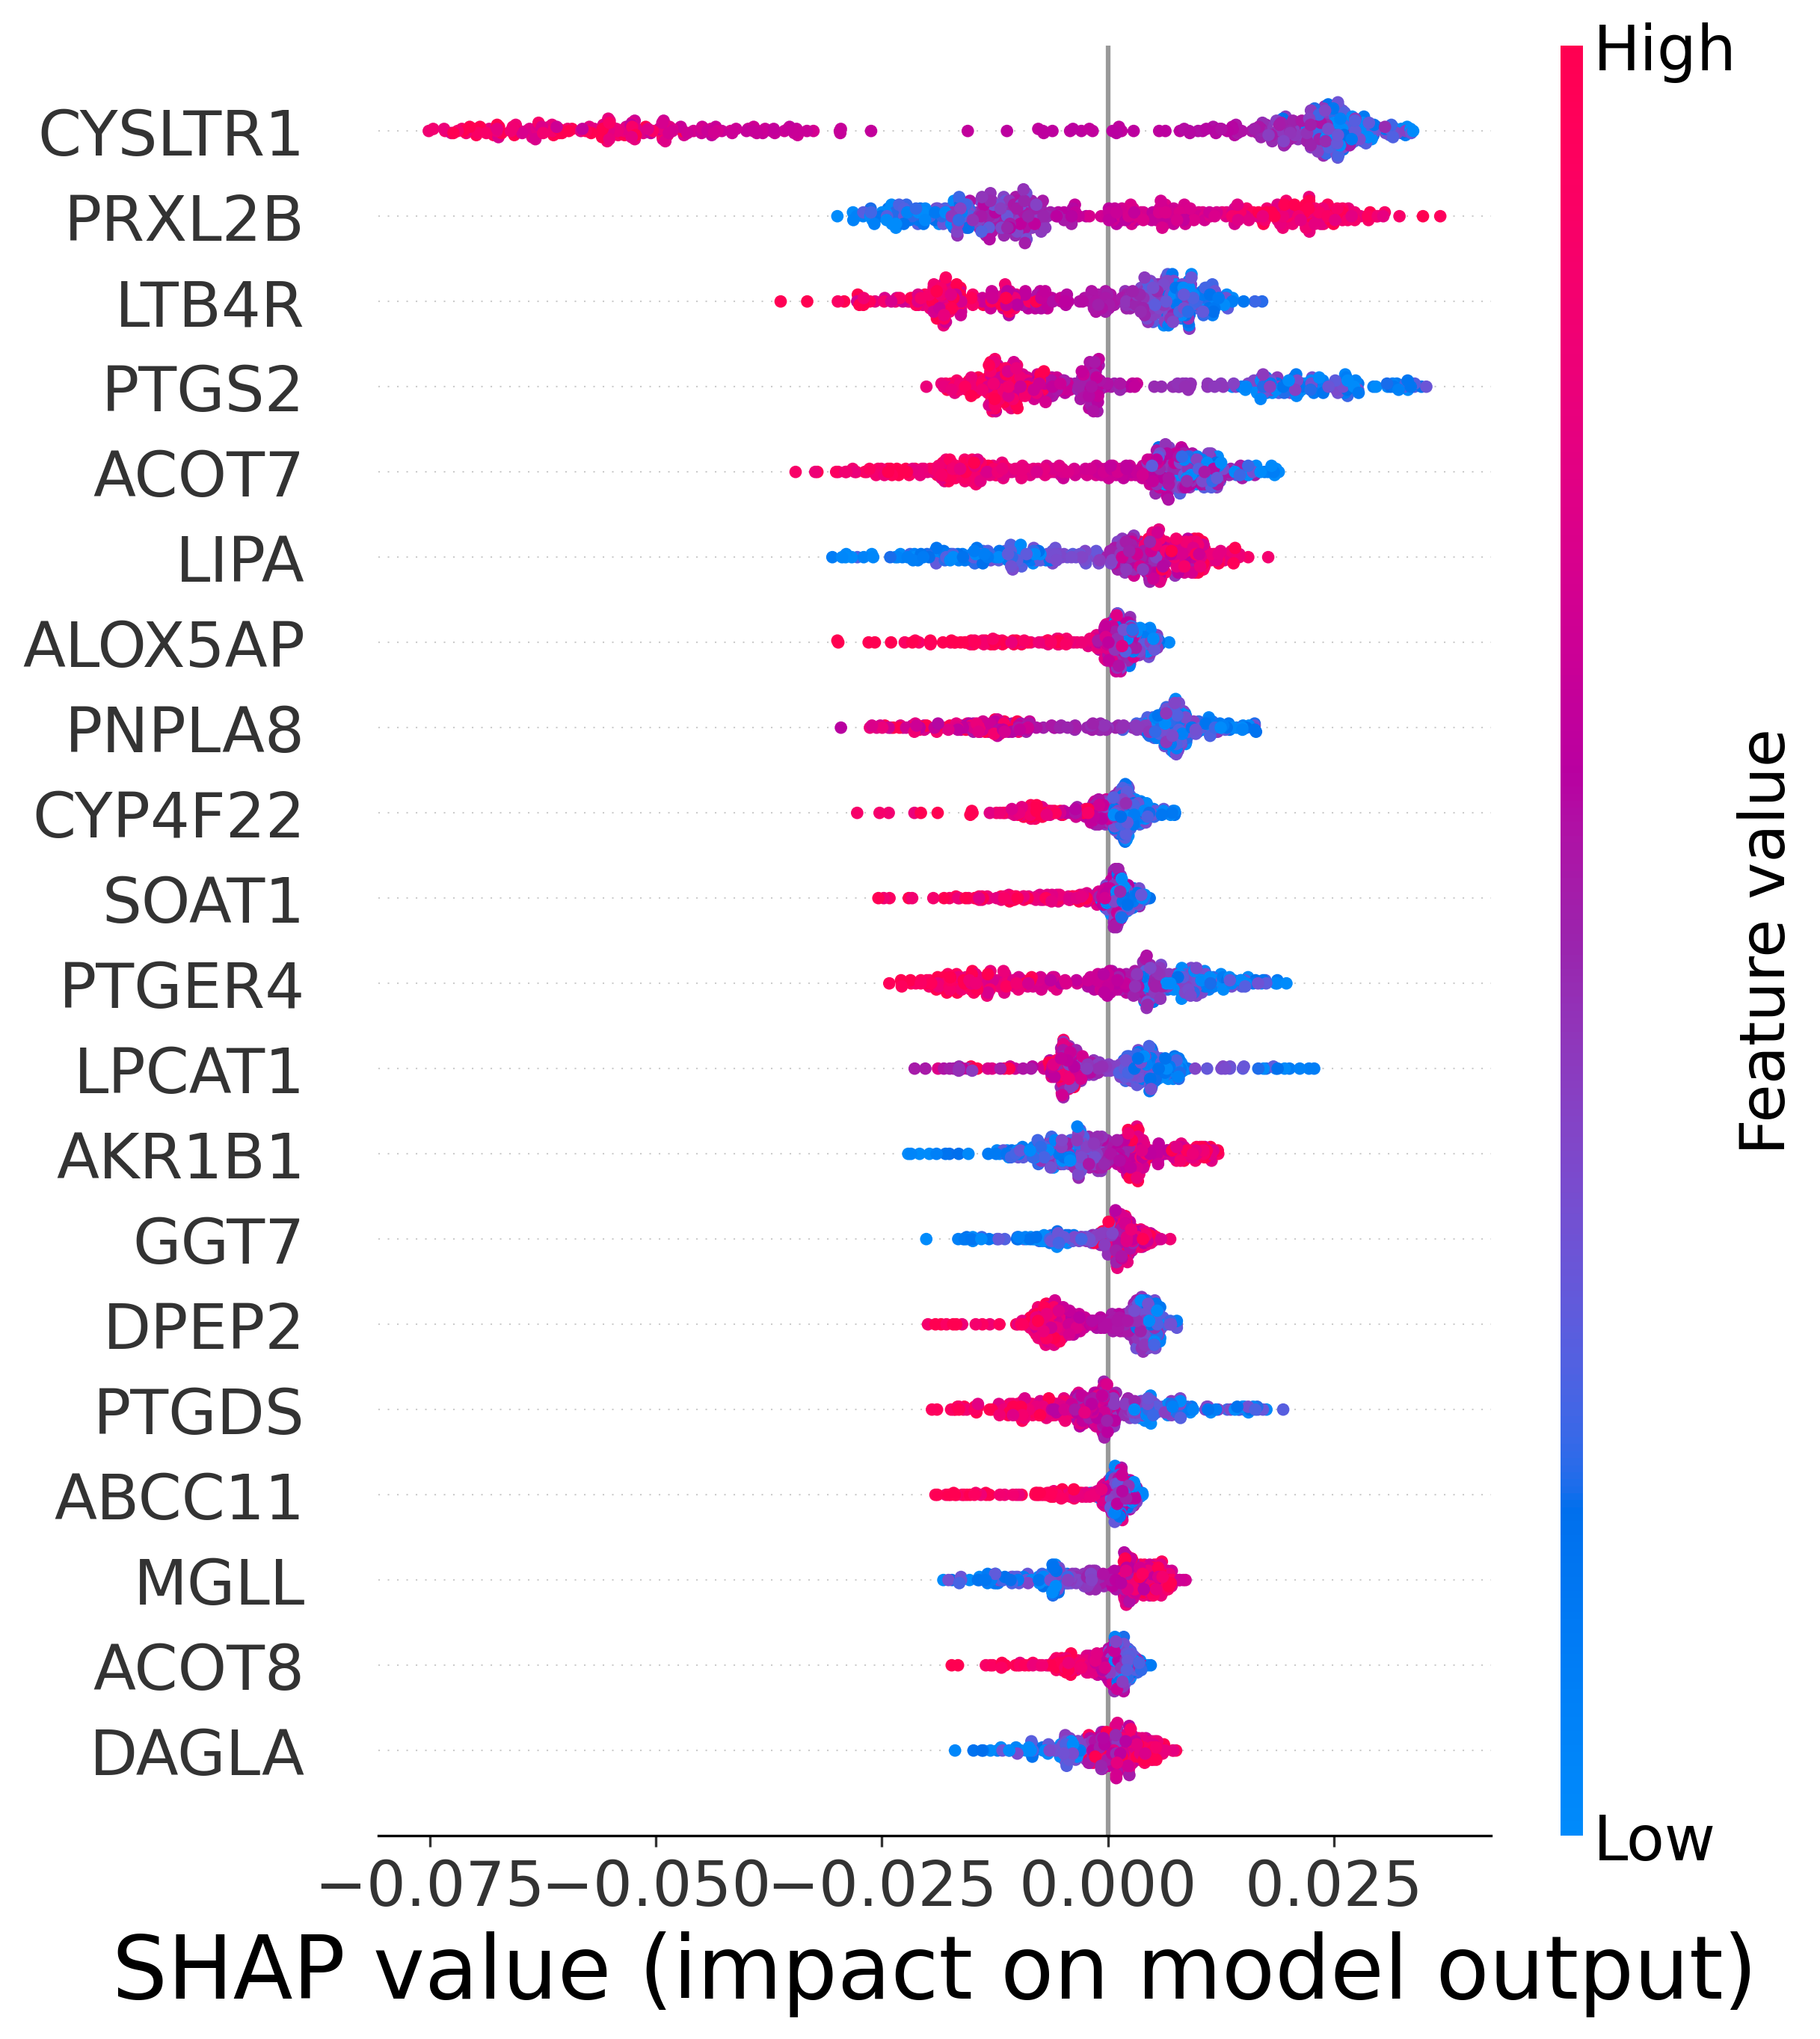

In [18]:
importance = np.max(np.abs(shap_all), axis=0)
order = np.argsort(importance)[::-1]

explanation = shap.Explanation(
    values=shap_all,
    data=X_test_all,
    feature_names=aap_symbols,
    base_values=expected_values
)
explanation.data = X_unscaled_test_all

fig = plt.figure(figsize=(12, 6), dpi=300)
shap.plots.beeswarm(explanation, max_display=20, show=False, order=order, group_remaining_features=False)
ax = plt.gca()
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=28)
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=20)
cbar.set_ylabel("Feature value", fontsize=20)
plt.subplots_adjust(top=0.95)
#fig.savefig(r"MA_Thesis/figures/RF/shap_summary_rf.pdf", bbox_inches="tight")
plt.show()
plt.close()

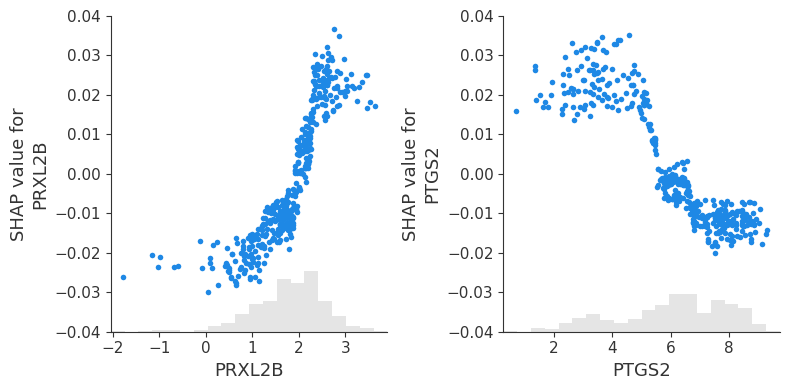

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.flatten()

#shap.plots.scatter(
#    explanation[:, "LTB4R"],
#    ax=axes[0],
#    show=False,
#)
shap.plots.scatter(
    explanation[:, "PRXL2B"],
    ax=axes[0],
    show=False,
)
shap.plots.scatter(
    explanation[:, "PTGS2"],
    ax=axes[1],
    show=False
)
#shap.plots.scatter(
#    explanation[:, "CYSLTR1"],
#    ax=axes[3],
#    show=False
#)

for ax in axes:
    ax.set_ylim(-0.04, 0.04)

plt.tight_layout()
#fig.savefig(OUTPUT_FIG / "scatter_plots.pdf", bbox_inches="tight")
plt.show()

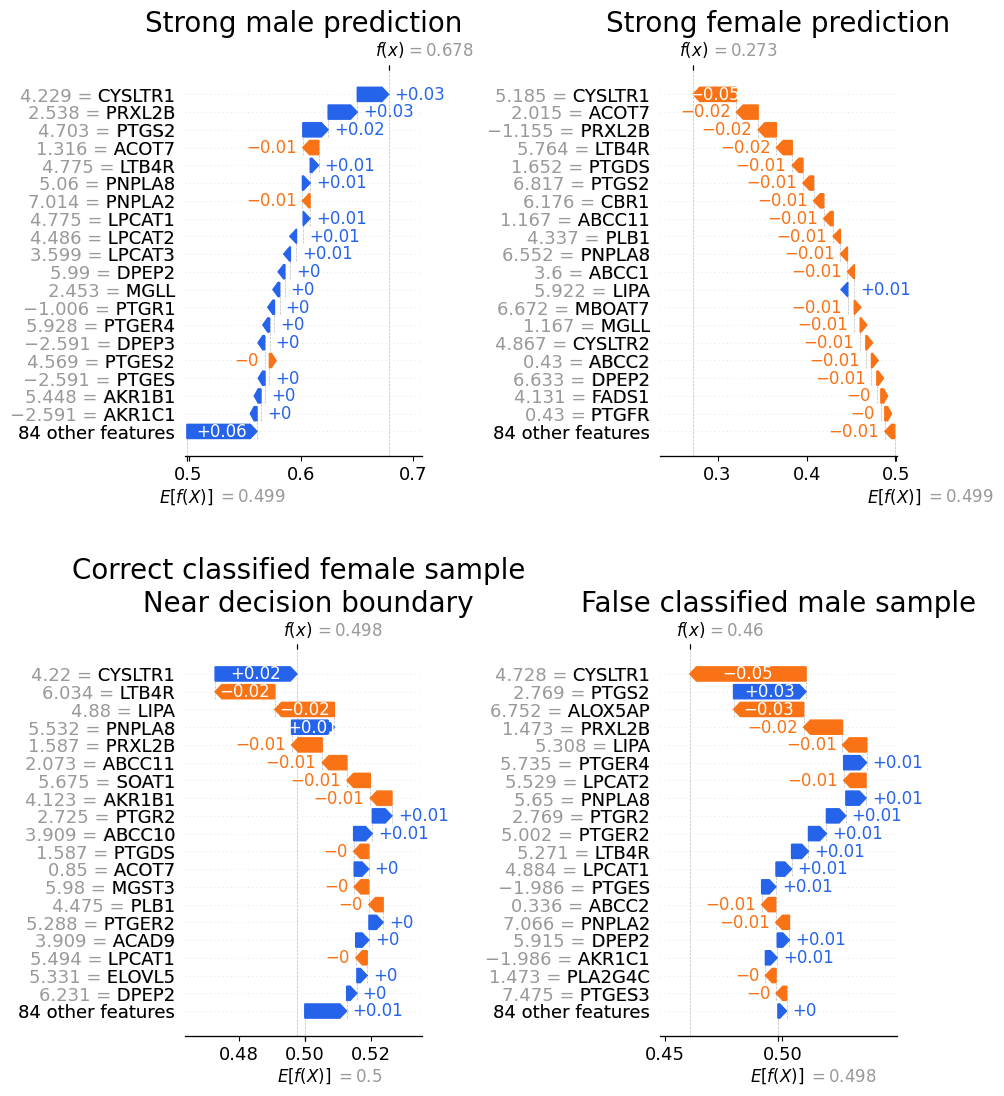

In [21]:
stacked_preds = np.hstack(all_y_pred)
stacked_trues = np.hstack(all_y_true)
stacked_probas = np.hstack(all_probas)

idx_high = np.argmax(stacked_probas)
idx_low = np.argsort(stacked_probas)[0]

#idx_median = np.argsort(stacked_probas)[len(stacked_probas) - 42]
idx_median = np.argsort(stacked_probas)[len(stacked_probas) // 2] - 10
idx_wrong = np.where(stacked_preds != stacked_trues)[0][0]

fig = plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)
shap.plots.waterfall(explanation[idx_high], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("Strong male prediction", fontsize=20)

plt.subplot(2, 2, 2)
shap.plots.waterfall(explanation[idx_low], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("Strong female prediction", fontsize=20)

plt.subplot(2, 2, 3)
shap.plots.waterfall(explanation[idx_median], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("Correct classified female sample \n Near decision boundary", fontsize=20)

plt.subplot(2, 2, 4)
shap.plots.waterfall(explanation[idx_wrong], show=False, max_display=20)
functions.recolor_shap_waterfall()
plt.title("False classified male sample", fontsize=20)

plt.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.08, wspace=1, hspace=0.5)
#fig.savefig(OUTPUT_FIG / "waterfall.pdf", bbox_inches="tight")
plt.show()

In [22]:
print(stacked_trues[idx_median], stacked_preds[idx_median])
print(stacked_trues[idx_wrong], stacked_preds[idx_wrong])

0 0
1 0
